## 1. Data exploration and preparation

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
import spacy
import networkx as nx
from wordcloud import WordCloud
from nltk.corpus import stopwords
from bertopic import BERTopic
from sklearn.linear_model              import LogisticRegression
from sklearn.model_selection           import cross_val_score, train_test_split
from sklearn.metrics                   import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score
from sklearn.feature_extraction.text   import CountVectorizer
from sklearn.preprocessing import LabelEncoder


### 1.1. Data Preparation: dropping small Subreddits

In [2]:
df = pd.read_csv('data/reddit_posts.csv')

In [3]:
df.Subreddit.value_counts()

Subreddit
conservatives          1000
alltheleft              997
SocialDemocracy         997
Libertarian             975
Capitalism              975
socialism               975
progressive             974
republicans             948
democrats               941
feminisms               935
DemocraticSocialism     922
Liberal                 904
anarchocapitalism       637
Communist               574
RadicalFeminism         100
Name: count, dtype: int64

We notice that subreddits are globally balanced, except for Anarchocapitalism, Communist, and RadicalFeminism. We will drop those subreddits with fewer posts. Also, the ethic commitee suggested that we drop some of the data.

In [4]:
df = df[~df['Subreddit'].isin(['Communist', 'RadicalFeminism', 'anarchocapitalism'])]
df.Subreddit.value_counts()


Subreddit
conservatives          1000
SocialDemocracy         997
alltheleft              997
socialism               975
Libertarian             975
Capitalism              975
progressive             974
republicans             948
democrats               941
feminisms               935
DemocraticSocialism     922
Liberal                 904
Name: count, dtype: int64

### 1.2 viewing scores and number of Comments

In [5]:
def plot_subreddit(column, x_max=400, y_max=500, bin_size=10):
    '''plots the distribution of a column in the subreddits'''
    axes = df[column].hist(
        by=df.Subreddit,
        bins=np.arange(0, x_max+1, bin_size),
        figsize=(12, 8),
        color='#08415C',  
    )
    plt.suptitle(f"Distributions of {column} in Subreddits.", fontsize=20, fontweight='bold', y=0.98)

    for ax in np.ravel(axes):
        ax.set_ylim(0, y_max)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if len(ax.patches) > 0:
            ax.patches[0].set_facecolor('#FF2C3D')
    plt.tight_layout()
    plt.show()

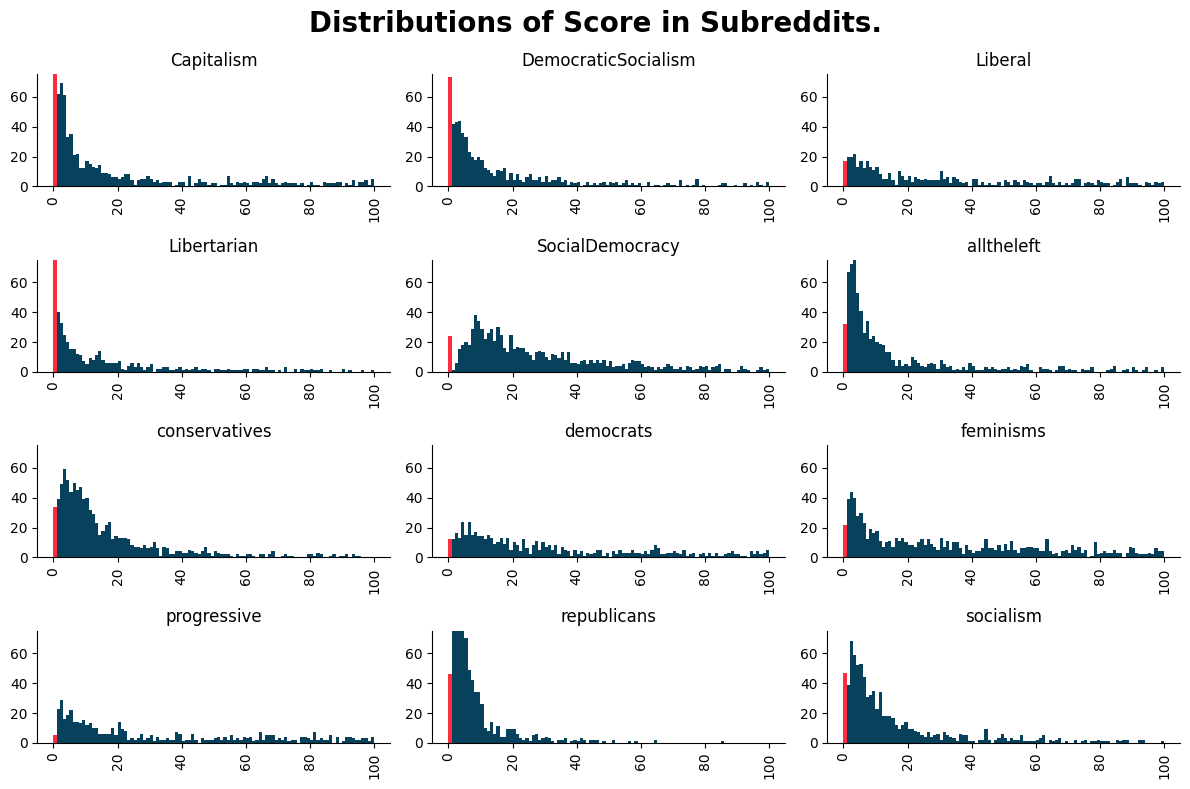

In [6]:
plot_subreddit("Score", 100, 75, 1)


We can see how popular posts are in different subreddits. Some have a lot of controversial posts with values close to 0 like *libertarian*. While others have a more uniform distribution like *feminisms*.

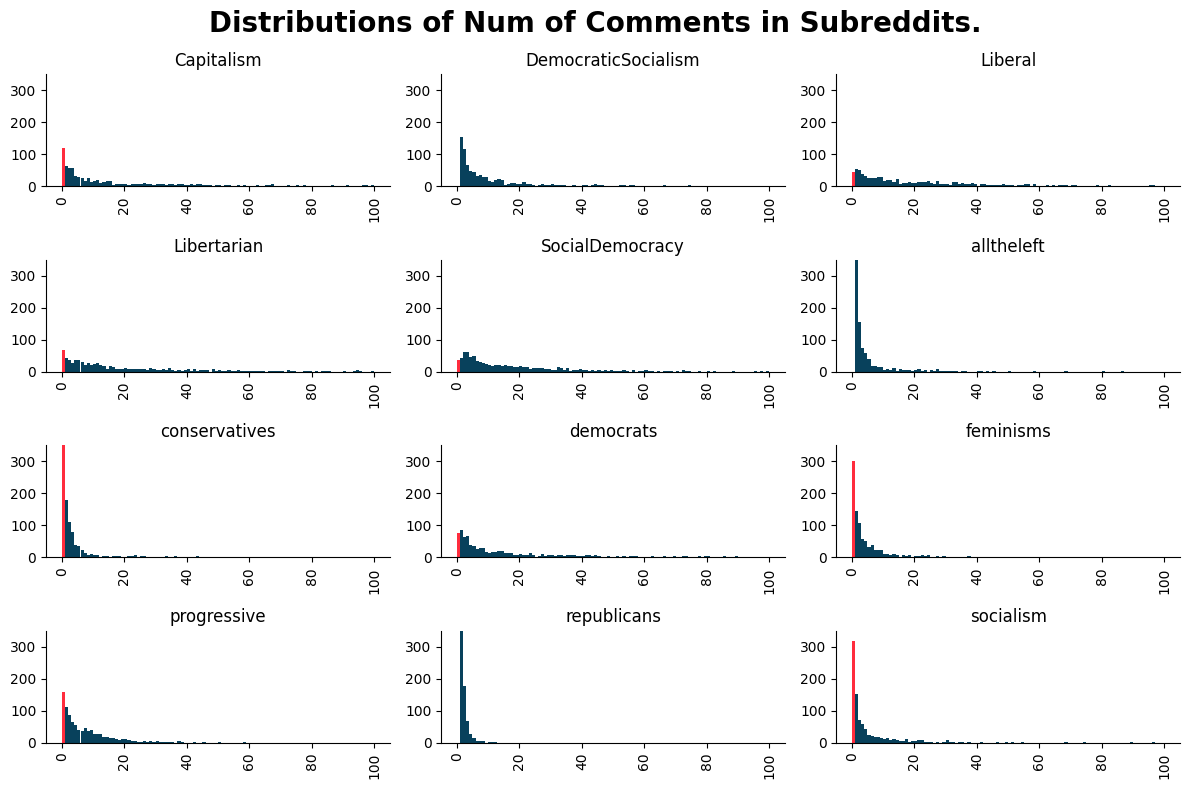

In [7]:
plot_subreddit('Num of Comments', 100, 350, 1)


Number of Comments really vary depending on the Subreddit. This can highlight different practices in subreddits. For instance *republicans* and *alltheleft* don't have posts with 0 comments while *conservativees* and *feminism* have a lot of them. This can be the difference between subbredits centered around for debates and discussions and subreddits made for posting.

## 2. Data preprocessing

### 2.1 removing urls, and standardising time

In [ ]:
df['Date Created'] = pd.to_datetime(df['Date Created'], unit='s')
df = df.rename(columns={"Title": "title", "Text": "selftext"})
combined = df['title'].fillna('') + ' ' + df['selftext'].fillna('')
url_pattern = r'https?://\S+'
has_url = combined.str.contains(url_pattern)
print(f"{has_url.sum()} posts contain URLs out of {len(df)} total")

df['title']    = df['title'].str.replace(url_pattern, '', regex=True)
df['selftext'] = df['selftext'].str.replace(url_pattern, '', regex=True)

565 posts contain URLs out of 11543 total


### 2.2 Removing short tokens, lemmatizing and removing stop words
To download the model, use 
```py
python -m spacy download en_core_web_sm
```

In [ ]:
spacy_tokenize = spacy.load(
    "en_core_web_sm",
    disable=["parser","ner","textcat"]
)

def clean_str(text: str) -> str:
    '''filters out non-alphabetic characters, short tokens and stop words, and lemmatizes'''
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    lemmas = [
        token.lemma_
        for token in spacy_tokenize(text)
        if token.is_alpha                
           and not token.is_stop        
           and len(token.lemma_) >= 3   
    ]
    return " ".join(lemmas)

df["title"]    = df["title"].apply(clean_str)
df["selftext"] = df["selftext"].apply(clean_str)

## 3. Topic Modelling

In [10]:
list(df.columns)


['title',
 'Political Lean',
 'Score',
 'Id',
 'Subreddit',
 'URL',
 'Num of Comments',
 'selftext',
 'Date Created']

In [11]:
list(df.Subreddit.unique())

['socialism',
 'democrats',
 'DemocraticSocialism',
 'SocialDemocracy',
 'progressive',
 'alltheleft',
 'Liberal',
 'feminisms',
 'Libertarian',
 'conservatives',
 'Capitalism',
 'republicans']

### 3.1 prepare the docs and labels for prediction

In [ ]:
docs = (df['title'].fillna('') + ' ' + df['selftext'].fillna('')).tolist()

# Encode Subreddit as integers
le = LabelEncoder()
y = le.fit_transform(df['Subreddit'])
subreddit_names = le.classes_


### 3.2 Fit BERTopic and Bet Topic Probabilities


In [13]:
topic_model = BERTopic(calculate_probabilities=True, verbose=True)
topics, probs = topic_model.fit_transform(docs)


2025-06-02 20:35:14,350 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/361 [00:00<?, ?it/s]

2025-06-02 20:36:00,223 - BERTopic - Embedding - Completed ✓
2025-06-02 20:36:00,224 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-06-02 20:36:17,421 - BERTopic - Dimensionality - Completed ✓
2025-06-02 20:36:17,422 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-06-02 20:36:28,179 - BERTopic - Cluster - Completed ✓
2025-06-02 20:36:28,184 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-06-02 20:36:28,415 - BERTopic - Representation - Completed ✓


## 4. Predicting Subreddit based on Topic Distribution

### 4.1 Predict Subreddit based on Topic distribution


5-fold CV Macro F1: 0.317 ± 0.024
                     precision    recall  f1-score   support

         Capitalism       0.34      0.47      0.39       195
DemocraticSocialism       0.43      0.09      0.14       184
            Liberal       0.31      0.19      0.24       181
        Libertarian       0.42      0.25      0.31       195
    SocialDemocracy       0.32      0.44      0.37       200
         alltheleft       0.15      0.17      0.16       199
      conservatives       0.33      0.34      0.33       200
          democrats       0.30      0.29      0.29       188
          feminisms       0.75      0.74      0.74       187
        progressive       0.22      0.27      0.25       195
        republicans       0.43      0.27      0.33       190
          socialism       0.21      0.37      0.27       195

           accuracy                           0.32      2309
          macro avg       0.35      0.32      0.32      2309
       weighted avg       0.35      0.32      0.3

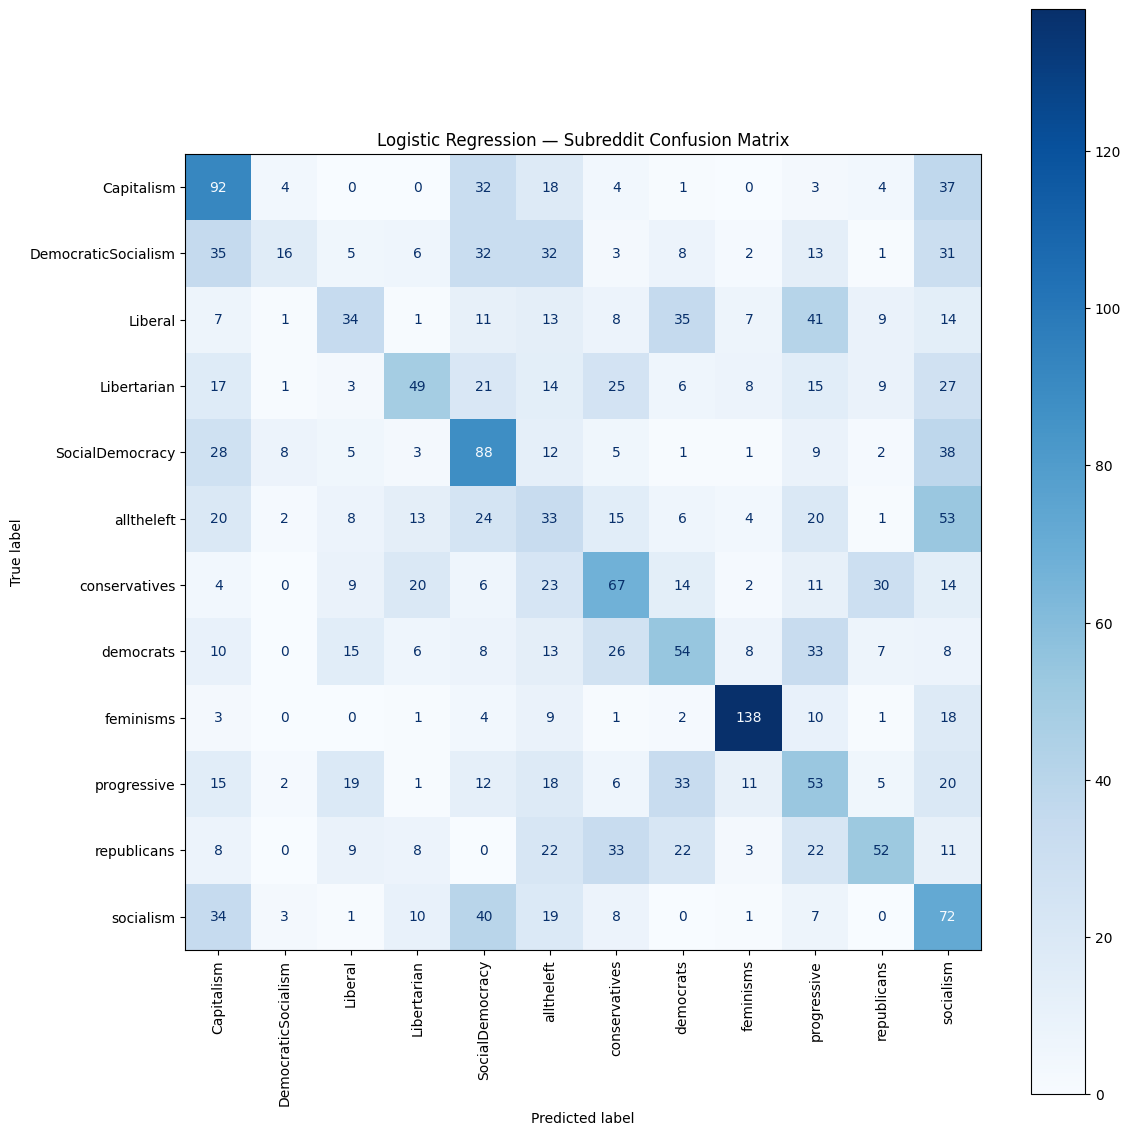

In [32]:
X = np.array(probs)  # shape: (n_docs, n_topics)


# 3. Evaluate with 5-Fold Cross-Validation (Macro F1)
clf = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs')
f1_scores = cross_val_score(clf, X, y, cv=5, scoring="f1_macro")
print(f"5-fold CV Macro F1: {f1_scores.mean():.3f} ± {f1_scores.std():.3f}")

# Train/test split for confusion matrix
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=subreddit_names))

conf_mat = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_mat, display_labels=subreddit_names)
fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=90)
plt.title("Logistic Regression — Subreddit Confusion Matrix")
plt.tight_layout()
plt.show()


We can see that subreddits are more or less identifiable from the topics, found in the corpus. In particular, *feminisms* is dealing with different topics than the rest of the dataset and is therefore easily identifiable, with an f1-score of 0.74. The rest of the dataset is quite uniform in topics dealt with. We can see relevant clusters of Subreddits being formed.

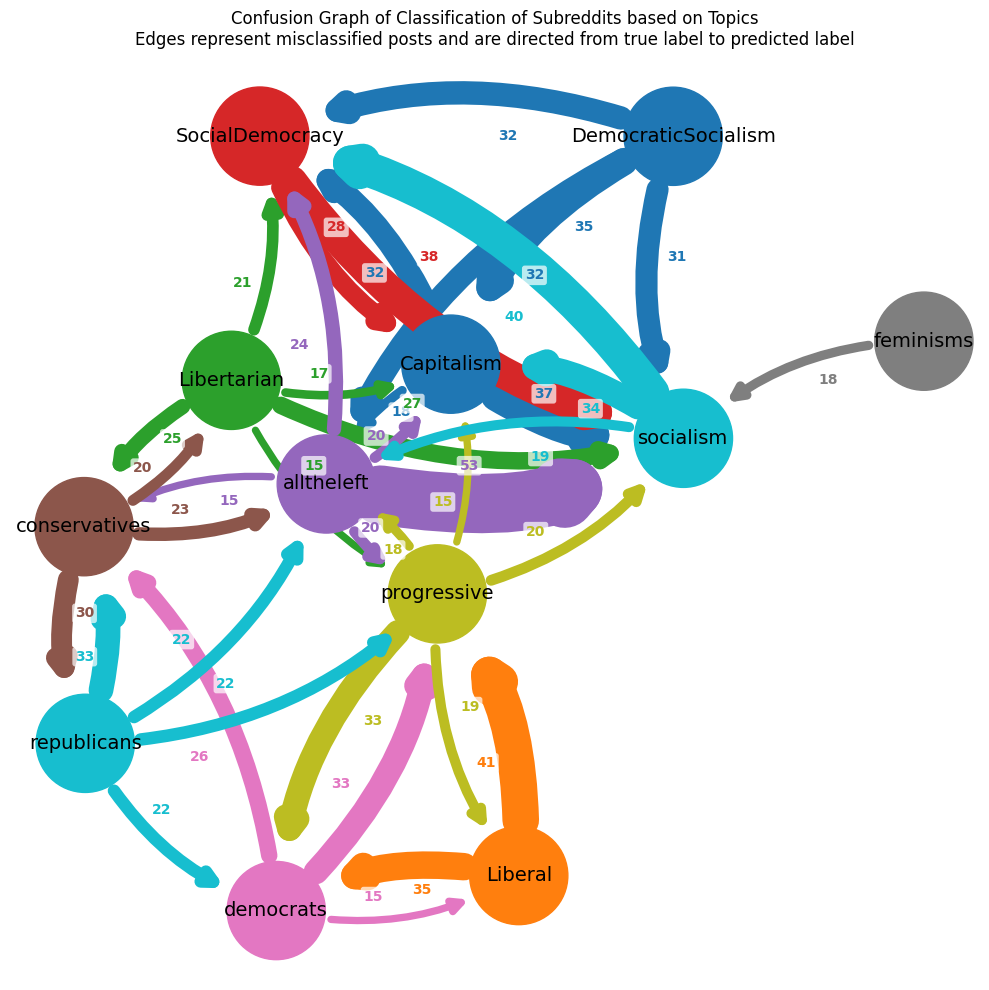

In [ ]:
n_classes = conf_mat.shape[0]
MIN_EDGE_WEIGHT = 14

G = nx.DiGraph()
for i in range(n_classes):
    G.add_node(subreddit_names[i])
for i in range(n_classes):
    for j in range(n_classes):
        if conf_mat[i, j] > MIN_EDGE_WEIGHT:
            G.add_edge(subreddit_names[i], subreddit_names[j], weight=conf_mat[i, j])
G.remove_edges_from(nx.selfloop_edges(G))

edge_labels = {(u, v): d['weight'] for u, v, d in G.edges(data=True)}
pos = nx.kamada_kawai_layout(G)
cmap = plt.get_cmap('tab10', n_classes)
node_colors = [cmap(i) for i in range(n_classes)]
node_color_dict = dict(zip(subreddit_names, node_colors))

plt.figure(figsize=(10, 10))
node_size = 5000
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_size)
node_radius = np.sqrt(node_size/np.pi)
for i, node in enumerate(subreddit_names):
    outgoing_edges = [(node, tgt) for tgt in subreddit_names if G.has_edge(node, tgt)]
    weights = [G[node][tgt]['weight'] for tgt in subreddit_names if G.has_edge(node, tgt)]
    widths = [1 + (w*w/np.max(conf_mat)) for w in weights]
    nx.draw_networkx_edges(
        G, pos,
        edgelist=outgoing_edges,
        edge_color=[node_colors[i]]*len(outgoing_edges),
        width=widths,
        arrowsize=20,
        alpha=1,
        connectionstyle='arc3,rad=0.2',
        min_source_margin=node_radius,
        min_target_margin=node_radius
    )
nx.draw_networkx_labels(G, pos, font_size=14, font_color='black')
ax = plt.gca()
for (u, v), label in edge_labels.items():
    x1, y1 = pos[u]
    x2, y2 = pos[v]
    label_x = 0.6 * x1 + 0.4 * x2
    label_y = 0.6 * y1 + 0.4 * y2
    ax.text(label_x, label_y, str(label), color=node_color_dict[u],
            fontsize=10, fontweight='bold', ha='center', va='center',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, boxstyle='round,pad=0.2'))
plt.title("Confusion Graph of Classification of Subreddits based on Topics\n"
          "Edges represent misclassified posts and are directed from true label to predicted label")
plt.axis('off')
plt.tight_layout()
plt.show()


Another way to visualize this 

### 4.2 Find Top Topics for Each Subreddit

In [15]:

# probs_df = pd.DataFrame(probs, columns=range(probs.shape[1]))
# probs_df["subreddit"] = y

# mean_by_subreddit = probs_df.groupby("subreddit").mean()

# # For each subreddit, get topics with highest mean probability
# top_n = 5
# for idx, subreddit in enumerate(subreddit_names):
#     top_topics = mean_by_subreddit.loc[idx].nlargest(top_n).index.tolist()
#     print(f"\nTop topics for {subreddit}: {top_topics}")
#     for tid in top_topics:
#         print(f"  === Topic {tid} ===")
#         for word, score in topic_model.get_topic(tid):
#             print(f"    {word:15} {score:.4f}")


## 5. Information Content of Topics in Subreddits

### 5.1 Compute Topic Distribution Across Subreddits

In [16]:
# DataFrame: each row is a document, columns are topic probabilities, plus 'Subreddit'
probs_df = pd.DataFrame(probs, columns=range(probs.shape[1]))
probs_df['Subreddit'] = df['Subreddit'].values

# Compute the mean probability of each topic in each subreddit
topic_by_sub = probs_df.groupby('Subreddit').mean().T  # shape: n_topics x n_subreddits

# Normalize so each topic's distribution across subreddits sums to 1
topic_by_sub_norm = topic_by_sub.div(topic_by_sub.sum(axis=1), axis=0)


### 5.2 Compute Information Content (Negative Entropy)

In [17]:
def entropy(p):
    p = p[p > 0]  # avoid log(0)
    return -np.sum(p * np.log2(p))

n_subreddits = topic_by_sub_norm.shape[1]
max_entropy = np.log2(n_subreddits)

info_content = topic_by_sub_norm.apply(entropy, axis=1)
info_content = max_entropy - info_content  # Higher = more informative


### 5.3 Select the 10 Most Informative Topics

Top 10 informative topics: [104, 6, 160, 19, 101, 111, 109, 4, 2, 40]


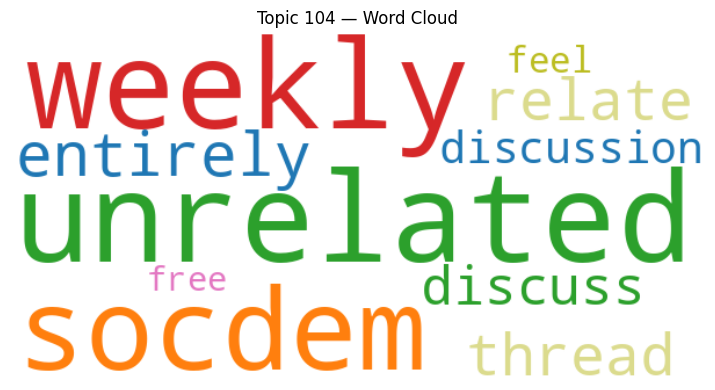

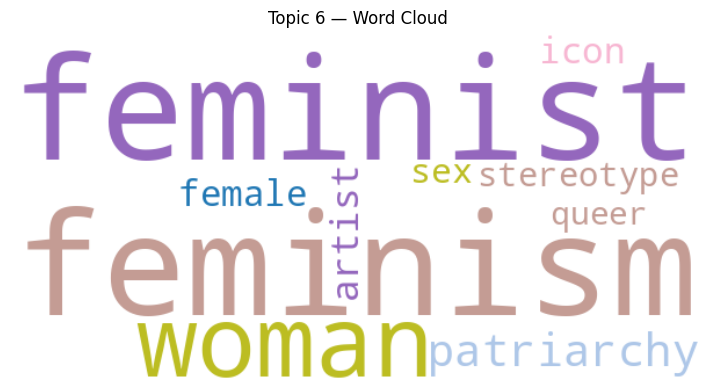

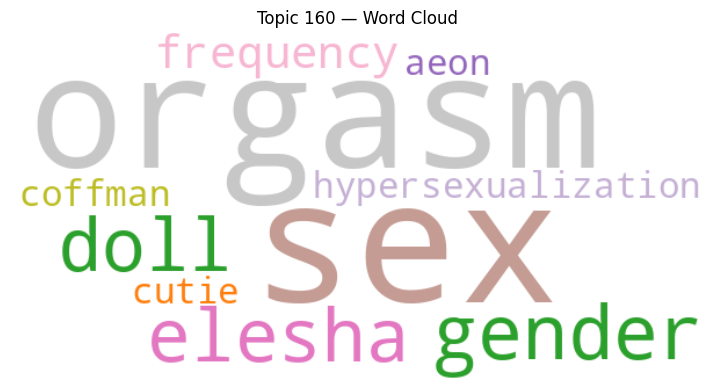

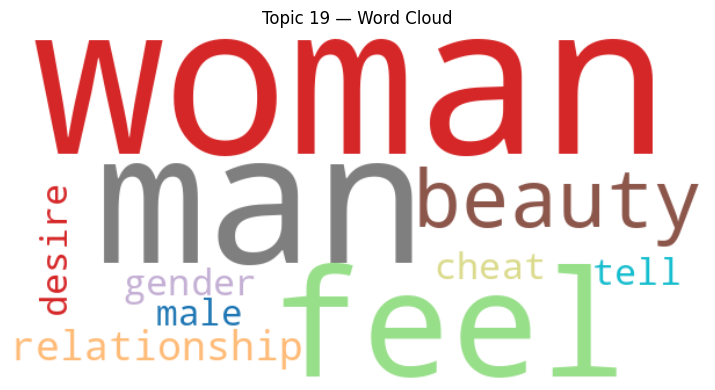

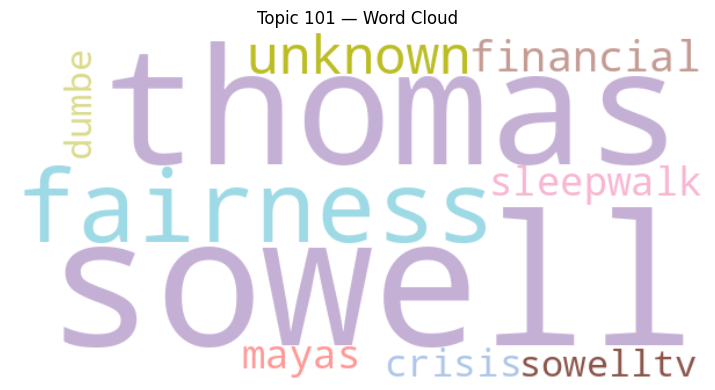

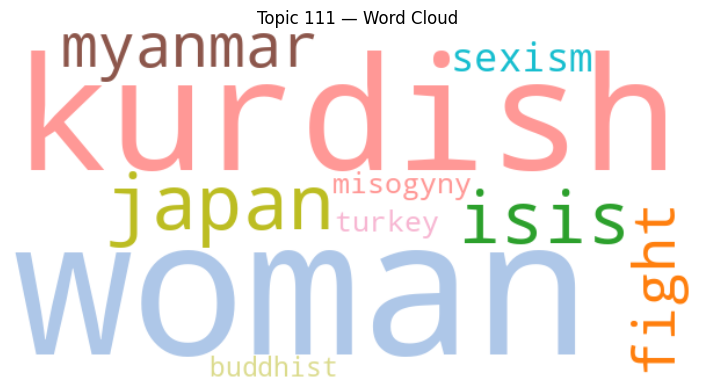

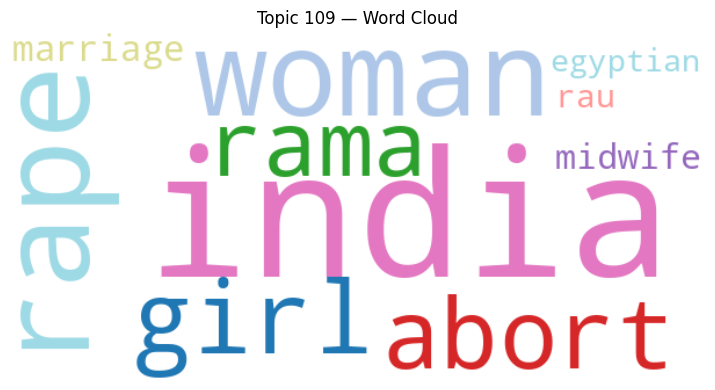

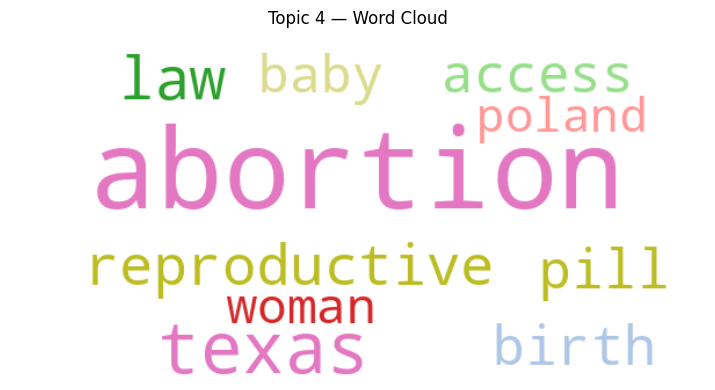

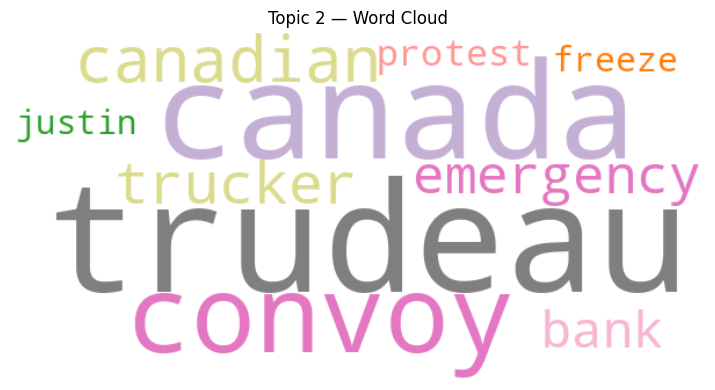

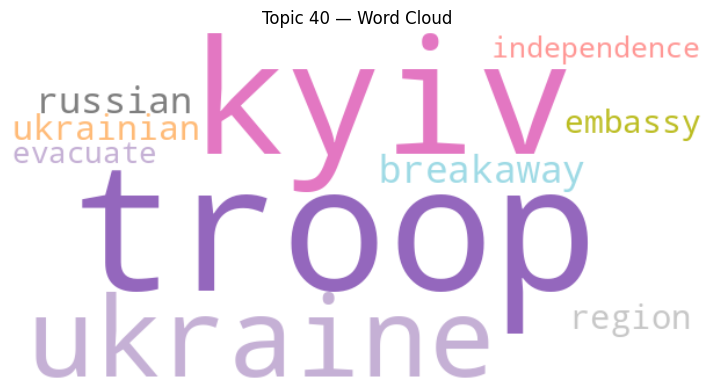

In [18]:
n_words = 10  # Number of top words to display per topic
top_topics = info_content.nlargest(n_words).index.tolist()
print(f"Top {n_words} informative topics:", top_topics)

for tid in top_topics:
    words_scores = topic_model.get_topic(tid)[:n_words]  # List of (word, score) tuples
    # Create a weighted string for the word cloud
    topic_words = []
    for word, score in words_scores:
        topic_words.extend([word] * int(score * 1000))  # Adjust multiplier as needed
    text = " ".join(topic_words)
    
    wordcloud = WordCloud(width=600, height=300, background_color="white",
                         colormap="tab20", collocations=False).generate(text)
    plt.figure(figsize=(8, 4))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Topic {tid} — Word Cloud")
    plt.tight_layout()
    plt.show()

### 5.4 Plot the Distribution Amongst Subreddits

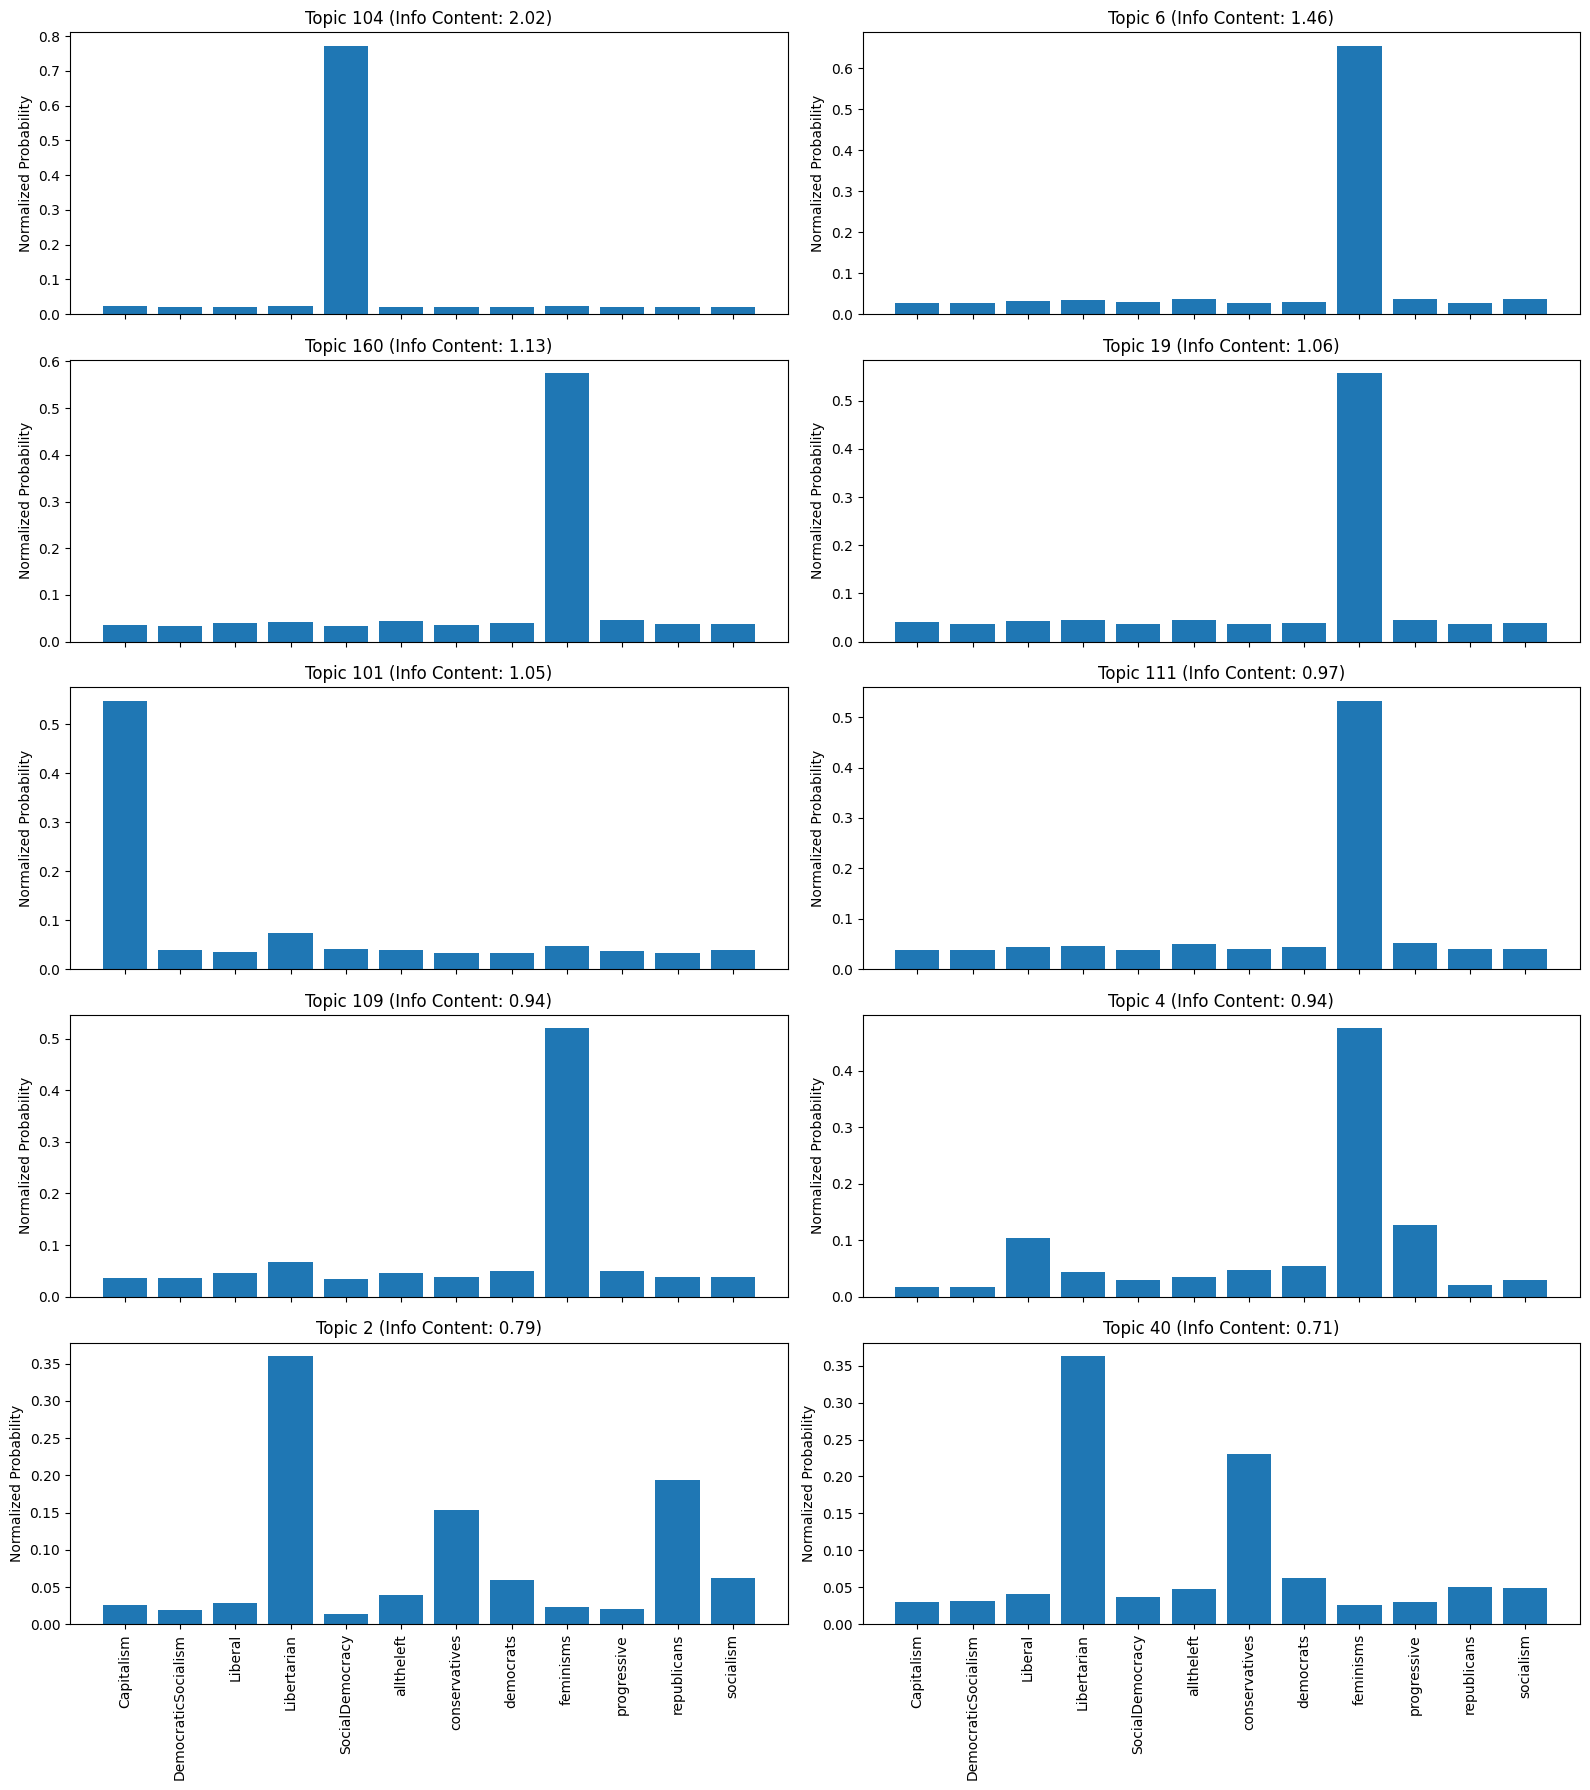

In [19]:
fig, axes = plt.subplots(5, 2, figsize=(16, 18), sharex=True)
axes = axes.flatten()

for i, tid in enumerate(top_topics):
    topic_dist = topic_by_sub_norm.loc[tid]
    axes[i].bar(topic_dist.index, topic_dist.values)
    axes[i].set_title(f"Topic {tid} (Info Content: {info_content[tid]:.2f})")
    axes[i].set_ylabel("Normalized Probability")
    axes[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()


### 5.5 Distribution of Topic Information

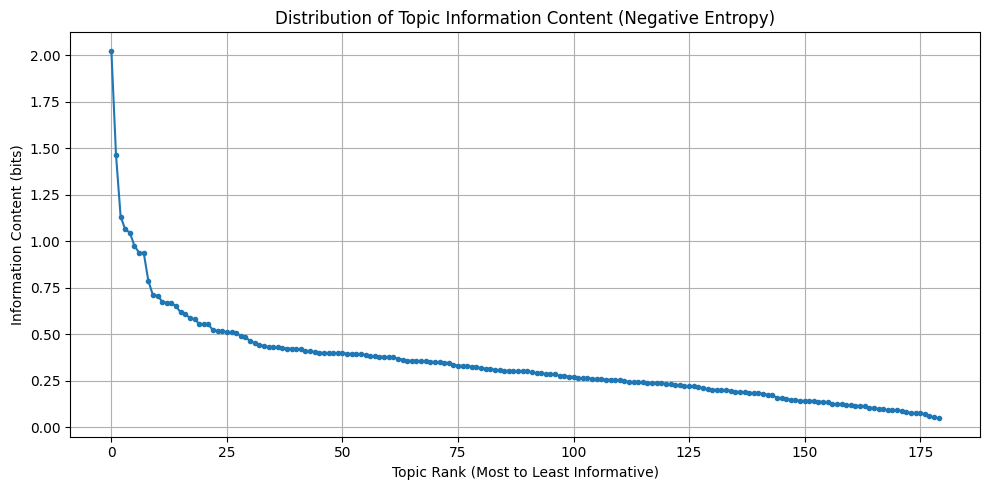

In [20]:
# info_content is a pandas Series: index=topic_id, value=information content (negative entropy)
sorted_info = info_content.sort_values(ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 5))
plt.plot(sorted_info.values, marker='.')
plt.title("Distribution of Topic Information Content (Negative Entropy)")
plt.xlabel("Topic Rank (Most to Least Informative)")
plt.ylabel("Information Content (bits)")
plt.grid(True)
plt.tight_layout()
plt.show()

Not all topics are very Informative. 

## 6. Predicting Subreddits based on Most Informative Subbredits
This approach is directly inspired by the TextNetTopics methodology, which recommends scoring and selecting the most discriminative topics for classification


### 6.1 Rank Topics by Information Content

In [21]:
sorted_topic_ids = info_content.sort_values(ascending=False).index.tolist()

### 6.2 Evaluate Classifier Performance with 1 to 100 Most Informative Topics

In [22]:
max_k = 100
scores = []

for k in range(1, max_k + 1):
    top_k = sorted_topic_ids[:k]
    X_k = probs[:, top_k]  # select columns for top-k topics
    clf = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs')
    # Use macro F1 for multiclass
    f1 = cross_val_score(clf, X_k, y, cv=5, scoring="f1_macro").mean()
    scores.append(f1)

### 6.3 Plot Performance Evolution

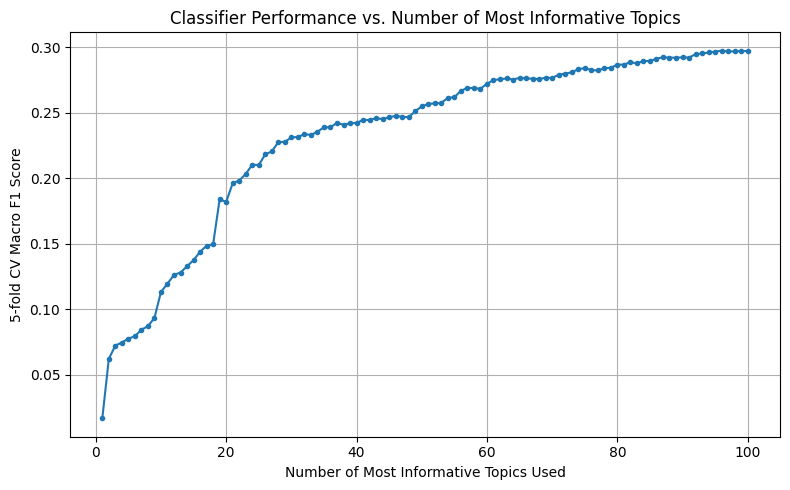

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, max_k + 1), scores, marker='.')
plt.xlabel('Number of Most Informative Topics Used')
plt.ylabel('5-fold CV Macro F1 Score')
plt.title('Classifier Performance vs. Number of Most Informative Topics')
plt.grid(True)
plt.tight_layout()
plt.show()


In our case, while this approach is better for simplicity and interpretability, it doesn't increase performances
